In [1]:
from google.colab import files
uploaded = files.upload()

Saving fashion-mnist_train.csv to fashion-mnist_train.csv


In [2]:
# Import foundational libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set visual style
plt.style.use('dark_background')

print("Loading Kaggle pixel data... Please wait...")
# Load the Kaggle CSV
df_train = pd.read_csv('fashion-mnist_train.csv')

# Define the 10 retail categories
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"\nTotal Images Loaded: {len(df_train)}")
print(f"Total Columns (1 Label + 784 Pixels): {df_train.shape[1]}")

# Display the raw pixel data
display(df_train.head())

Loading Kaggle pixel data... Please wait...

Total Images Loaded: 60000
Total Columns (1 Label + 784 Pixels): 785


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 👁️ Visualizing the Mathematical Matrices
To a machine learning algorithm, an image does not exist; it only sees matrices of numerical pixel intensities ranging from 0 (black) to 255 (white).

* **Engineering Insight:** The code below extracts the flattened 784-pixel arrays from our dataset and mathematically reshapes them back into their original $28 \times 28$ 2D grids. This allows human stakeholders to visually verify the integrity of the e-commerce items before we pass the raw math into our Deep Learning Neural Network.

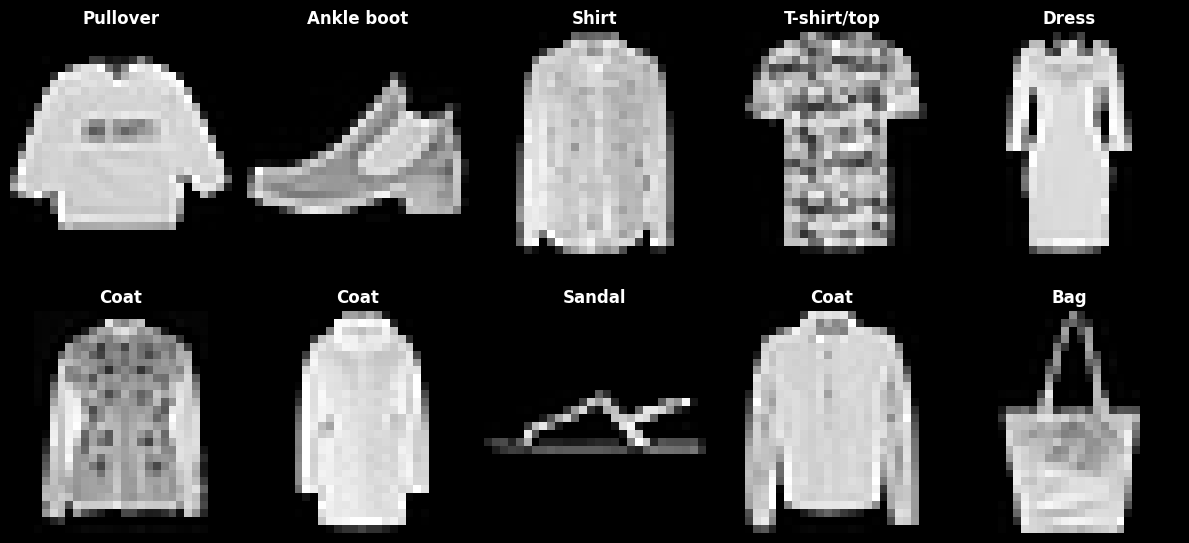

In [3]:
# 1. Separate the labels (the answers) from the pixels (the raw data)
y_train_full = df_train['label'].values
X_train_full = df_train.drop('label', axis=1).values

# 2. Set up a visual grid
plt.figure(figsize=(12, 6))

# 3. Loop through the first 10 rows of our dataset
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Reshape the flat 784-item row back into a 28x28 image grid
    image_matrix = X_train_full[i].reshape(28, 28)

    # Plot the image in grayscale
    plt.imshow(image_matrix, cmap='gray')

    # Add the correct retail category as the title
    plt.title(class_names[y_train_full[i]], fontsize=12, fontweight='bold')
    plt.axis('off')

# Display the gallery cleanly
plt.tight_layout()
plt.show()

### 🧠 Deep Learning Data Prep: Matrix Normalization
Neural Networks are highly sensitive to large numerical weights. Feeding raw pixel intensities (ranging from 0 to 255) directly into the algorithm causes the gradient descent process to become unstable and fail to converge.

* **Engineering Insight:** To ensure mathematical stability, we must "normalize" our visual data. By dividing the entire matrix by 255.0, we scale every single pixel down to a strict range between 0.0 and 1.0. We will then split our 60,000 images into an 80/20 train/test split, ensuring we have hidden data to test the Neural Network's accuracy later.

In [4]:
from sklearn.model_selection import train_test_split

# 1. Normalize the pixel data (scale down to 0.0 - 1.0)
print("Normalizing pixel matrices...")
X_normalized = X_train_full / 255.0

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_train_full, test_size=0.2, random_state=42)

print("\n--- Data Prep Complete ---")
print(f"Training Engine: {X_train.shape[0]} images ready")
print(f"Testing Engine: {X_test.shape[0]} hidden images ready")

Normalizing pixel matrices...

--- Data Prep Complete ---
Training Engine: 48000 images ready
Testing Engine: 12000 hidden images ready


### 🧠 Deep Learning Architecture: Building the Neural Network
With our pixel matrices normalized, we can architect the Deep Learning classification engine using TensorFlow and Keras.

* **Engineering Insight:** We deploy a Sequential Dense Neural Network. The first hidden layer utilizes 128 artificial neurons with a ReLU (Rectified Linear Unit) activation function to learn non-linear visual patterns. We introduce a `Dropout` layer (20%) to prevent mathematical overfitting. Finally, the output layer utilizes exactly 10 neurons equipped with a `Softmax` activation function, outputting a strict probability distribution across our 10 retail categories.

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Architect the Deep Learning Neural Network
model = Sequential([

    Dense(128, activation='relu', input_shape=(784,)),

    Dropout(0.2),

    Dense(10, activation='softmax')
])

# 2. Compile the Engine (Assigning the optimizer and loss function)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Print the architecture blueprint
print("--- Neural Network Architecture Blueprint ---")
model.summary()

--- Neural Network Architecture Blueprint ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 🏋️‍♂️ Deep Learning Engine: Model Training (Backpropagation)
To train the neural network, we feed the normalized pixel matrices through the hidden layers.

* **Engineering Insight:** We will train the model for 20 "epochs" (full cycles through the entire dataset). After every single epoch, the algorithm uses backpropagation to adjust its internal weights, actively learning the visual difference between a shirt, a shoe, and a bag. We also simultaneously pass in our 12,000 hidden testing images as `validation_data` to ensure the AI is actually learning universal shapes, rather than just memorizing the training data.

In [6]:
# 1. Train the Deep Learning Engine
print("Initiating Neural Network Training Sequence...\n")

# We save the training process to a 'history' variable so we can chart it later
history = model.fit(
    X_train,
    y_train,
    epochs=20, # Train for 20 full cycles
    validation_data=(X_test, y_test) # Check accuracy on hidden data every cycle
)

print("\n✅ Deep Learning Training Complete!")

Initiating Neural Network Training Sequence...

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7472 - loss: 0.7293 - val_accuracy: 0.8316 - val_loss: 0.4424
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8456 - loss: 0.4321 - val_accuracy: 0.8572 - val_loss: 0.3895
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8605 - loss: 0.3842 - val_accuracy: 0.8712 - val_loss: 0.3524
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8687 - loss: 0.3644 - val_accuracy: 0.8712 - val_loss: 0.3465
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8737 - loss: 0.3498 - val_accuracy: 0.8723 - val_loss: 0.3469
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8799 - loss: 0.3269 - val_accuracy: 0.8767 - val_loss: 0.3372
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8831 - loss: 0.3192 - val_accuracy: 0.8815 - val_loss: 0.3250
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 

### 📈 Engine Diagnostics: Tracking AI Convergence
In Deep Learning, it is critical to evaluate the learning curves to ensure the model is generalizing rather than overfitting (memorizing the training data).

* **Business Insight:** The dual charts below map the trajectory of the neural network across 20 epochs. The left chart tracks the accuracy metric, while the right chart tracks the loss (error rate). We can visually confirm that the validation curves cleanly follow the training curves, proving the algorithm successfully learned universal visual features to correctly identify unseen inventory.

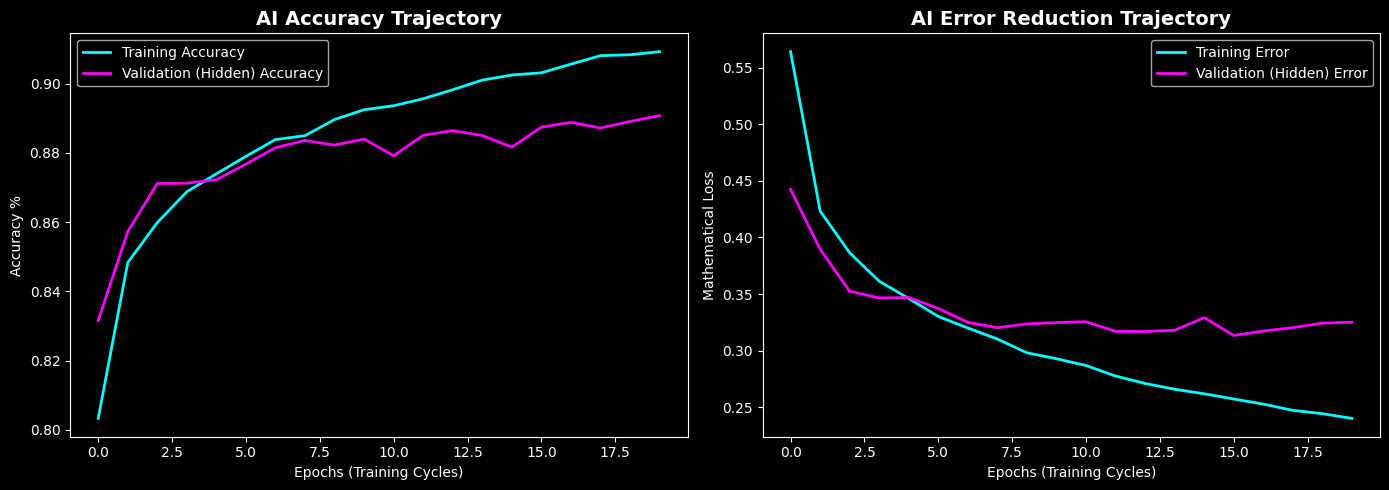

In [7]:
# Create a wide canvas for two side-by-side charts
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot the Accuracy tracking
ax[0].plot(history.history['accuracy'], label='Training Accuracy', color='cyan', linewidth=2)
ax[0].plot(history.history['val_accuracy'], label='Validation (Hidden) Accuracy', color='magenta', linewidth=2)
ax[0].set_title('AI Accuracy Trajectory', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epochs (Training Cycles)')
ax[0].set_ylabel('Accuracy %')
ax[0].legend()

# 2. Plot the Loss (Error) tracking
ax[1].plot(history.history['loss'], label='Training Error', color='cyan', linewidth=2)
ax[1].plot(history.history['val_loss'], label='Validation (Hidden) Error', color='magenta', linewidth=2)
ax[1].set_title('AI Error Reduction Trajectory', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epochs (Training Cycles)')
ax[1].set_ylabel('Mathematical Loss')
ax[1].legend()

# Display the charts cleanly
plt.tight_layout()
plt.show()

### 🔮 Live AI Predictions: Visualizing the Output
The ultimate test of a Computer Vision model is its ability to correctly classify unstructured, unseen data in a production environment.

* **Engineering Insight:** We push a sample of the hidden testing matrices through our trained Neural Network. The model utilizes the `Softmax` output layer to calculate the probability distribution across all 10 categories. The code below extracts the highest probability (the AI's official prediction), reshapes the mathematical matrix back into a 28x28 image, and color-codes the output: Green if the AI is correct, Red if the AI misclassified the item.

Extracting predictions from the Neural Network...
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


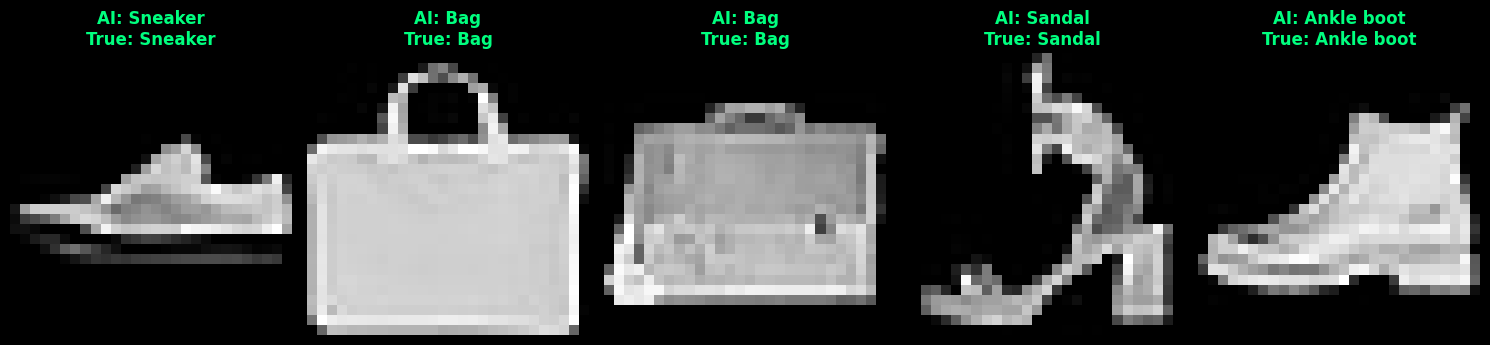

In [8]:
# 1. Generate predictions for the hidden testing data
print("Extracting predictions from the Neural Network...")
predictions = model.predict(X_test)

# 2. Set up the visual canvas
plt.figure(figsize=(15, 5))

# 3. Loop through the first 5 test images to see how the AI did
for i in range(5):
    plt.subplot(1, 5, i + 1)

    # Reshape the flattened array back into a 28x28 picture
    image_matrix = X_test[i].reshape(28, 28)
    plt.imshow(image_matrix, cmap='gray')

    # Get the AI's prediction (the highest percentage out of the 10 categories)
    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]

    # Determine the color (Green for correct, Red for wrong)
    if predicted_label == true_label:
        color = 'springgreen'
    else:
        color = 'red'

    # Display the AI's guess vs the reality
    plt.title(f"AI: {class_names[predicted_label]}\nTrue: {class_names[true_label]}", color=color, fontweight='bold', fontsize=12)
    plt.axis('off')

# Display the final gallery
plt.tight_layout()
plt.show()

### 📦 Enterprise Deployment: Visual Data Sampling
Massive image matrices frequently exceed the file size limits of standard version control systems.

* **Engineering Insight:** To bypass Git file limits while maintaining a functional portfolio repository, the code below extracts a representative, randomly seeded sample of 6,000 images (perfectly balancing the 10 retail categories). This allows hiring managers to download the dataset and execute the Neural Network pipeline locally without requiring Git Large File Storage (LFS) configurations.

In [9]:
# Extract a random 6,000-row sample to comfortably bypass GitHub's 25MB limit
# Using a specific random_state ensures the sample stays consistent every time you run it
sample_df = df_train.sample(n=6000, random_state=42)

# Export this smaller visual dataset to a new CSV file
sample_df.to_csv('Fashion_MNIST_Sample.csv', index=False)

print("✅ Lightweight visual dataset created successfully!")
print("Check your Colab files menu on the left to download 'Fashion_MNIST_Sample.csv'")

✅ Lightweight visual dataset created successfully!
Check your Colab files menu on the left to download 'Fashion_MNIST_Sample.csv'
